# Context Heterogeneity Analysis for Embedding-Based FL Partitioning

## Mathematical Formulation

Given $K=13$ global semantic clusters from DINOv2 embeddings, each client $c$ has a **cluster distribution** $P_c \in \Delta^{K-1}$ (probability simplex) representing its mix of scene contexts.

### KL-Divergence (Client vs. Global)

$$D_{\text{KL}}(P_c \| Q) = \sum_{k=1}^{K} P_c(k) \log \frac{P_c(k)}{Q(k)}$$

where $Q$ is the global cluster distribution. Measures how much client $c$'s scene-context mix diverges from the population.

### Jensen-Shannon Divergence (Symmetric, Bounded)

$$\text{JSD}(P_c \| Q) = \frac{1}{2} D_{\text{KL}}(P_c \| M) + \frac{1}{2} D_{\text{KL}}(Q \| M), \quad M = \frac{P_c + Q}{2}$$

Bounded in $[0, \log 2]$, symmetric, and well-defined even for zero-probability clusters.

### Interpretation: Context Heterogeneity

Since each 1024-d DINOv2 vector represents a **full scene** (not a pixel class), the cluster distribution captures the *scene-context mix* (e.g., highway, residential, urban). The divergence therefore measures **Context Heterogeneity** — how different a client's visual environment is from the population average.

In [6]:
# ============================================================
# Cell 1: Imports & Configuration
# ============================================================
import json
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import entropy
from scipy.spatial.distance import jensenshannon, cosine

# ── Style ──
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (14, 5),
    "axes.titleweight": "bold",
})

# ── Paths (edit these if your files live elsewhere) ──
BASE_DIR = Path(".")
EMBEDDINGS_PATH   = BASE_DIR / "embeddings.pth"
CLUSTERS_PATH     = BASE_DIR / "clusters_global.pth"

# Partition files to compare
PARTITION_FILES = {
    "IID  (α=100)":   BASE_DIR / "iid_partitions.json",
    "Non-IID (α=0.1)": BASE_DIR / "non_iid_partitions.json",
}

# Number of clusters
K = 13

# Laplace smoothing constant (avoids log(0))
EPSILON = 1e-10

print("✓ Configuration ready")

✓ Configuration ready


## 1 · Load Global Data (Embeddings + Clusters)

In [7]:
# ============================================================
# Cell 2: Load embeddings & clusters, build filename → index map
# ============================================================

# ── Load .pth files ──
emb_data = torch.load(EMBEDDINGS_PATH, map_location="cpu", weights_only=False)
cls_data = torch.load(CLUSTERS_PATH,   map_location="cpu", weights_only=False)

embeddings     = emb_data["embeddings"].numpy()          # (2975, 1024)
cluster_labels = cls_data["cluster_labels"]               # (2975,)  int32
centroids      = cls_data["centroids"]                    # (13, 1024)
image_paths    = cls_data["image_paths"]                  # list[str]
n_clusters     = cls_data["n_clusters"]                   # 13
n_samples      = cls_data["n_samples"]                    # 2975

# ── Build a lookup: filename → global index ──
# JSON uses relative paths ("leftImg8bit/train/city/file.png")
# .pth uses absolute Kaggle paths; match on the FILENAME only.
filename_to_idx = {}
for idx, p in enumerate(image_paths):
    fname = os.path.basename(p)          # "aachen_000000_000019_leftImg8bit.png"
    filename_to_idx[fname] = idx

# ── Global cluster distribution Q ──
global_counts = np.bincount(cluster_labels, minlength=K).astype(float)
Q_global      = global_counts / global_counts.sum()       # (K,)

print(f"Loaded {n_samples} samples, {n_clusters} clusters, embedding dim = {embeddings.shape[1]}")
print(f"Global cluster distribution Q:\n  {np.round(Q_global, 4)}")
print(f"Cluster sizes: {dict(enumerate(global_counts.astype(int)))}")

Loaded 2975 samples, 13 clusters, embedding dim = 1024
Global cluster distribution Q:
  [0.0642 0.0776 0.0514 0.0649 0.0682 0.0985 0.1096 0.0847 0.0487 0.0938
 0.0861 0.0803 0.0719]
Cluster sizes: {0: np.int64(191), 1: np.int64(231), 2: np.int64(153), 3: np.int64(193), 4: np.int64(203), 5: np.int64(293), 6: np.int64(326), 7: np.int64(252), 8: np.int64(145), 9: np.int64(279), 10: np.int64(256), 11: np.int64(239), 12: np.int64(214)}


## 2 · Helper Functions: Mapping & Metrics

In [8]:
# ============================================================
# Cell 3: Core helper functions
# ============================================================

def load_partition(json_path: str | Path) -> dict:
    """Load a partition JSON and return the raw dict."""
    with open(json_path, "r") as f:
        return json.load(f)


def map_clients_to_clusters(
    partition: dict,
    filename_to_idx: dict,
    cluster_labels: np.ndarray,
    K: int,
) -> dict:
    """
    For each client in the partition JSON, find its images in the
    global cluster data and build:
      - cluster_hist:  raw counts per cluster  (K,)
      - cluster_dist:  normalised distribution (K,)
      - global_indices: list of matched global indices

    Returns
    -------
    client_info : dict[str, dict]
        Keyed by client_id string.
    """
    client_info = {}
    missed = 0
    for cid, cdata in partition.items():
        indices = []
        for img_path, _lbl_path in cdata["data"]:
            fname = os.path.basename(img_path)
            if fname in filename_to_idx:
                indices.append(filename_to_idx[fname])
            else:
                missed += 1

        labels  = cluster_labels[indices]
        hist    = np.bincount(labels, minlength=K).astype(float)
        dist    = hist / hist.sum() if hist.sum() > 0 else np.ones(K) / K

        client_info[cid] = {
            "client_name":    cdata.get("client_name", cid),
            "n_samples":      len(indices),
            "global_indices": indices,
            "cluster_hist":   hist,
            "cluster_dist":   dist,
        }

    if missed:
        print(f"⚠  {missed} image(s) could not be matched (filename mismatch)")
    return client_info


# ── Divergence helpers ──

def kl_divergence(P: np.ndarray, Q: np.ndarray, eps: float = EPSILON) -> float:
    """KL(P || Q) with Laplace smoothing."""
    P_s = P + eps
    Q_s = Q + eps
    P_s /= P_s.sum()
    Q_s /= Q_s.sum()
    return float(entropy(P_s, Q_s))          # scipy uses natural log → nats


def js_divergence(P: np.ndarray, Q: np.ndarray) -> float:
    """Jensen-Shannon divergence (squared JSD; base-2)."""
    return float(jensenshannon(P, Q) ** 2)   # scipy returns √JSD


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """1 – cosine distance."""
    return float(1.0 - cosine(a, b))


def compute_heterogeneity(
    client_info: dict,
    Q_global: np.ndarray,
    embeddings: np.ndarray,
) -> list[dict]:
    """
    Compute per-client heterogeneity metrics and return a list of
    records (ready for display / DataFrame).
    """
    global_mean_emb = embeddings.mean(axis=0)
    records = []
    for cid, info in client_info.items():
        P_c = info["cluster_dist"]
        client_embs = embeddings[info["global_indices"]]
        client_mean = client_embs.mean(axis=0) if len(client_embs) > 0 else global_mean_emb

        records.append({
            "client_id":     cid,
            "client_name":   info["client_name"],
            "n_samples":     info["n_samples"],
            "KL_div":        kl_divergence(P_c, Q_global),
            "JSD":           js_divergence(P_c, Q_global),
            "cos_sim":       cosine_similarity(client_mean, global_mean_emb),
            "cluster_dist":  P_c,
            "cluster_hist":  info["cluster_hist"],
        })

    # Sort by JSD descending for easy inspection
    records.sort(key=lambda r: r["JSD"], reverse=True)
    return records

print("✓ Helper functions defined")

✓ Helper functions defined


## 3 · Run Heterogeneity Analysis on All Partition Settings

In [9]:
# ============================================================
# Cell 4: Run analysis for every partition setting
# ============================================================

all_results = {}   # setting_name → list[dict]

for setting_name, json_path in PARTITION_FILES.items():
    print(f"\n{'='*60}")
    print(f"  Setting: {setting_name}")
    print(f"  File:    {json_path}")
    print(f"{'='*60}")

    partition   = load_partition(json_path)
    client_info = map_clients_to_clusters(partition, filename_to_idx, cluster_labels, K)
    records     = compute_heterogeneity(client_info, Q_global, embeddings)
    all_results[setting_name] = records

    # ── Summary statistics ──
    kls  = [r["KL_div"] for r in records]
    jsds = [r["JSD"]    for r in records]
    coss = [r["cos_sim"] for r in records]

    print(f"\n  Clients: {len(records)}")
    print(f"  KL-Div   →  mean={np.mean(kls):.4f}  std={np.std(kls):.4f}  "
          f"min={np.min(kls):.4f}  max={np.max(kls):.4f}")
    print(f"  JSD      →  mean={np.mean(jsds):.4f}  std={np.std(jsds):.4f}  "
          f"min={np.min(jsds):.4f}  max={np.max(jsds):.4f}")
    print(f"  Cos-Sim  →  mean={np.mean(coss):.4f}  std={np.std(coss):.4f}  "
          f"min={np.min(coss):.4f}  max={np.max(coss):.4f}")

    # ── Per-client table (top-10 most heterogeneous) ──
    print(f"\n  Top-10 most heterogeneous clients (by JSD):")
    print(f"  {'Client':<12} {'Samples':>8} {'KL-Div':>10} {'JSD':>10} {'Cos-Sim':>10}")
    print(f"  {'-'*52}")
    for r in records[:10]:
        print(f"  {r['client_name']:<12} {r['n_samples']:>8} "
              f"{r['KL_div']:>10.4f} {r['JSD']:>10.4f} {r['cos_sim']:>10.4f}")


  Setting: IID  (α=100)
  File:    iid_partitions.json

  Clients: 20
  KL-Div   →  mean=0.0093  std=0.0028  min=0.0023  max=0.0137
  JSD      →  mean=0.0023  std=0.0007  min=0.0006  max=0.0035
  Cos-Sim  →  mean=0.9962  std=0.0006  min=0.9947  max=0.9970

  Top-10 most heterogeneous clients (by JSD):
  Client        Samples     KL-Div        JSD    Cos-Sim
  ----------------------------------------------------
  client_0          145     0.0137     0.0035     0.9961
  client_10         149     0.0131     0.0033     0.9959
  client_9          154     0.0125     0.0032     0.9958
  client_3          156     0.0119     0.0030     0.9957
  client_16         148     0.0119     0.0030     0.9966
  client_18         139     0.0116     0.0029     0.9965
  client_8          152     0.0106     0.0027     0.9963
  client_5          150     0.0102     0.0026     0.9967
  client_1          154     0.0099     0.0025     0.9970
  client_15         150     0.0094     0.0024     0.9966

  Setting: No

## 4 · Visualization: Per-Client Cluster Distributions

/tmp/ipykernel_132449/3666629649.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", K)


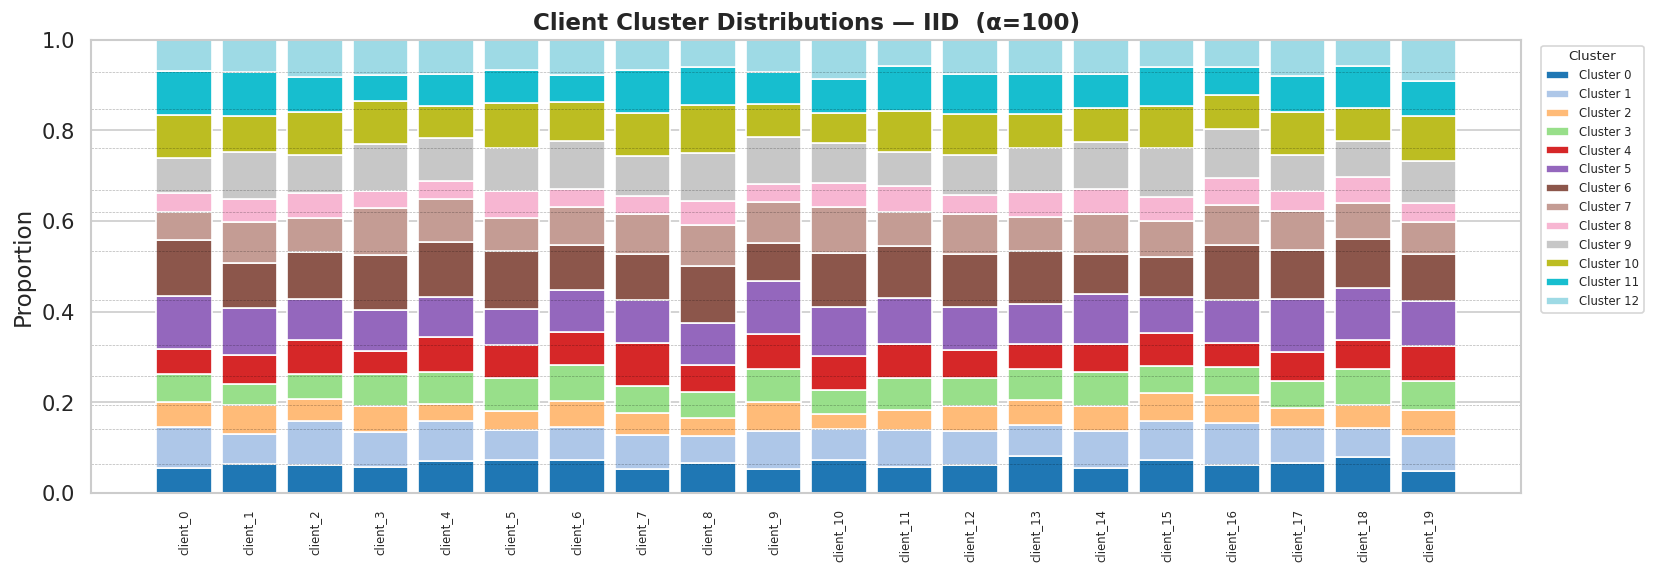

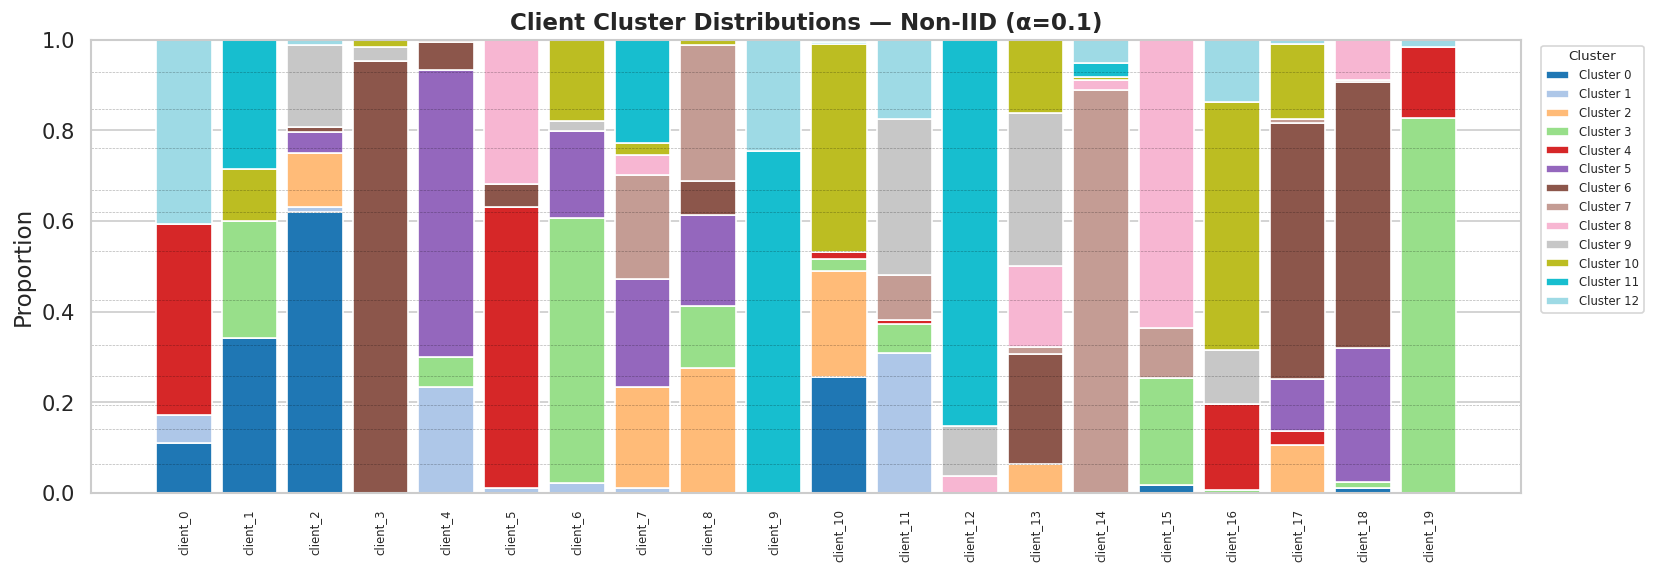

In [10]:
# ============================================================
# Cell 5: Stacked bar chart — cluster distribution per client
# ============================================================

cmap = plt.cm.get_cmap("tab20", K)

for setting_name, records in all_results.items():
    n_clients = len(records)
    fig, ax = plt.subplots(figsize=(max(14, n_clients * 0.35), 5))

    # Sort by client_id for consistent ordering
    sorted_recs = sorted(records, key=lambda r: int(r["client_id"]))
    client_labels = [r["client_name"] for r in sorted_recs]
    dists = np.array([r["cluster_dist"] for r in sorted_recs])   # (C, K)

    bottom = np.zeros(n_clients)
    for k in range(K):
        ax.bar(
            range(n_clients), dists[:, k], bottom=bottom,
            color=cmap(k), label=f"Cluster {k}", width=0.85,
        )
        bottom += dists[:, k]

    # Overlay the global distribution as horizontal dashed lines
    cumsum = 0
    for k in range(K):
        ax.axhline(cumsum + Q_global[k], color="black", ls="--", lw=0.4, alpha=0.3)
        cumsum += Q_global[k]

    ax.set_xticks(range(n_clients))
    ax.set_xticklabels(client_labels, rotation=90, fontsize=7)
    ax.set_ylabel("Proportion")
    ax.set_title(f"Client Cluster Distributions — {setting_name}")
    ax.set_ylim(0, 1.0)
    ax.legend(
        loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7,
        ncol=1, title="Cluster", title_fontsize=8,
    )
    fig.tight_layout()
    plt.show()

## 5 · Visualization: KL-Divergence & JSD per Client

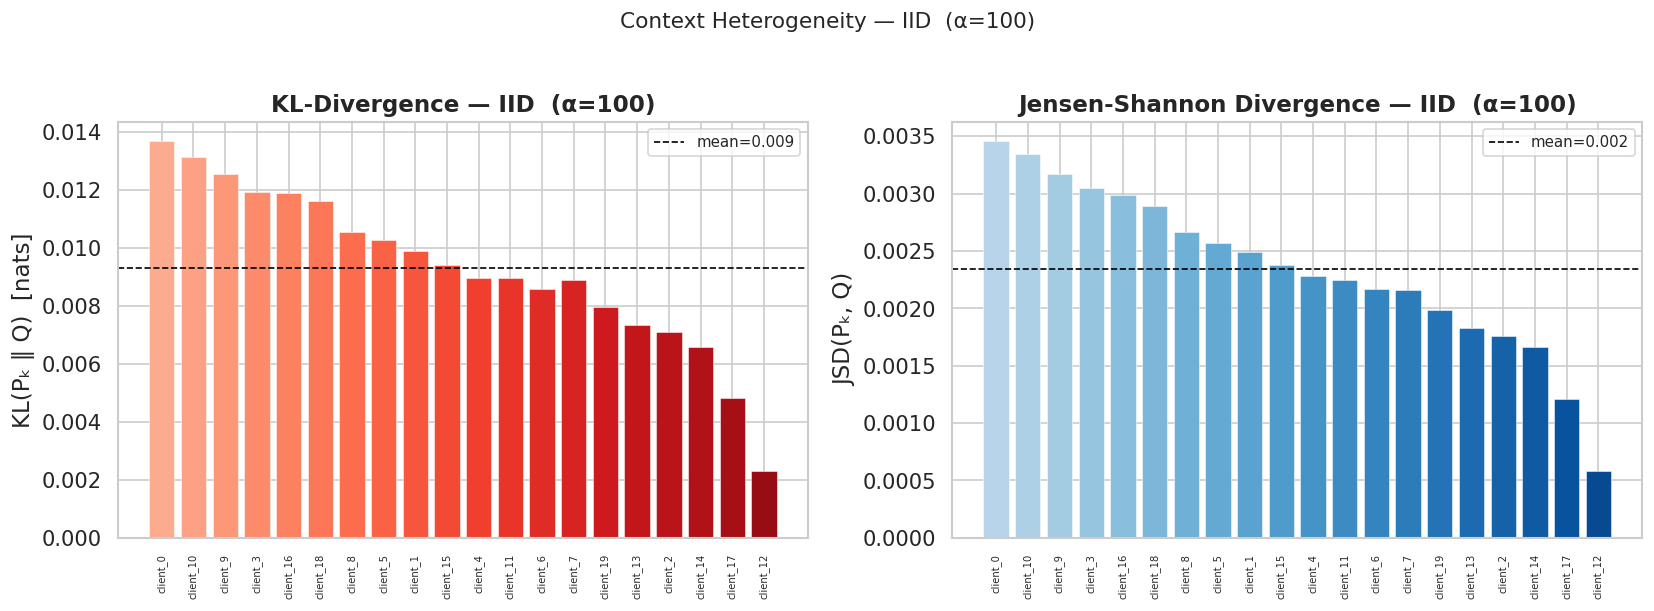

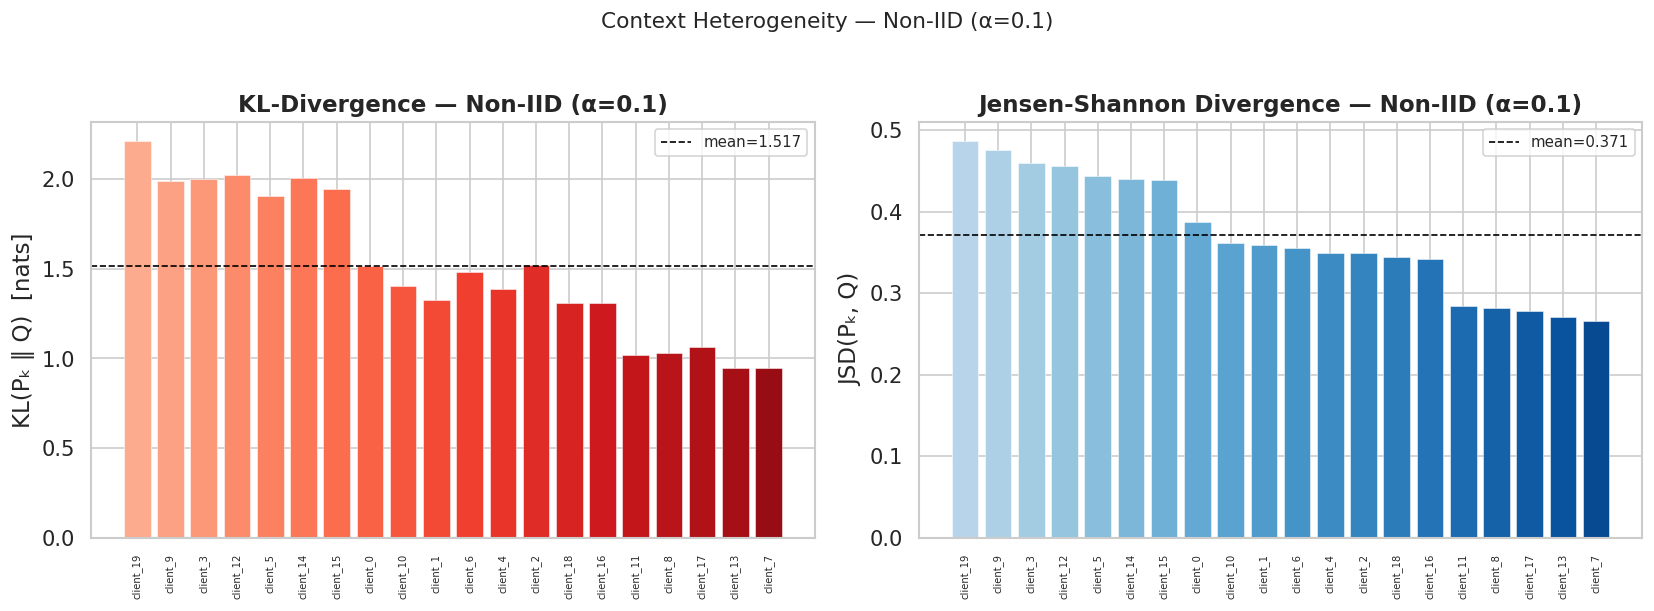

In [11]:
# ============================================================
# Cell 6: Bar charts — KL & JSD per client (side by side per setting)
# ============================================================

for setting_name, records in all_results.items():
    n = len(records)

    # Sort by JSD descending
    sorted_recs = sorted(records, key=lambda r: r["JSD"], reverse=True)
    names = [r["client_name"] for r in sorted_recs]
    kls   = [r["KL_div"] for r in sorted_recs]
    jsds  = [r["JSD"]    for r in sorted_recs]

    fig, axes = plt.subplots(1, 2, figsize=(max(14, n * 0.35), 5))

    # ── KL Divergence ──
    colors_kl = plt.cm.Reds(np.linspace(0.3, 0.9, n))
    axes[0].bar(range(n), kls, color=colors_kl, edgecolor="white", lw=0.3)
    axes[0].axhline(np.mean(kls), color="black", ls="--", lw=1, label=f"mean={np.mean(kls):.3f}")
    axes[0].set_xticks(range(n))
    axes[0].set_xticklabels(names, rotation=90, fontsize=6)
    axes[0].set_ylabel("KL(Pₖ ‖ Q)  [nats]")
    axes[0].set_title(f"KL-Divergence — {setting_name}")
    axes[0].legend(fontsize=9)

    # ── JSD ──
    colors_js = plt.cm.Blues(np.linspace(0.3, 0.9, n))
    axes[1].bar(range(n), jsds, color=colors_js, edgecolor="white", lw=0.3)
    axes[1].axhline(np.mean(jsds), color="black", ls="--", lw=1, label=f"mean={np.mean(jsds):.3f}")
    axes[1].set_xticks(range(n))
    axes[1].set_xticklabels(names, rotation=90, fontsize=6)
    axes[1].set_ylabel("JSD(Pₖ, Q)")
    axes[1].set_title(f"Jensen-Shannon Divergence — {setting_name}")
    axes[1].legend(fontsize=9)

    fig.suptitle(f"Context Heterogeneity — {setting_name}", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

## 6 · Pairwise JSD Heatmap (Client × Client)

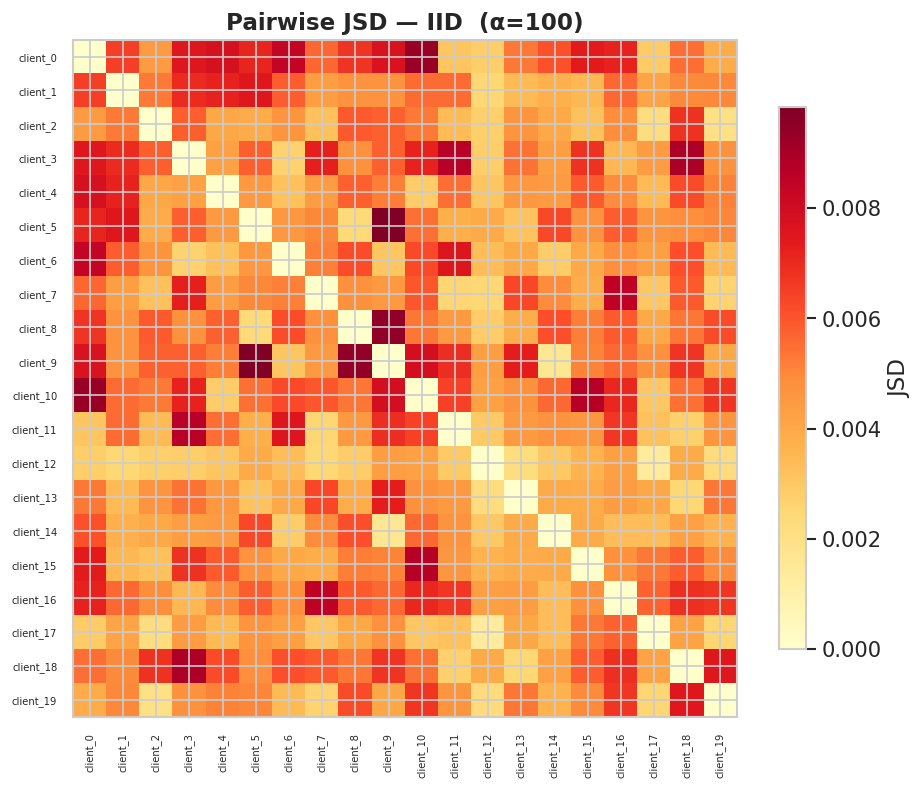

  IID  (α=100)  →  Pairwise JSD: mean=0.0049  std=0.0017  max=0.0098


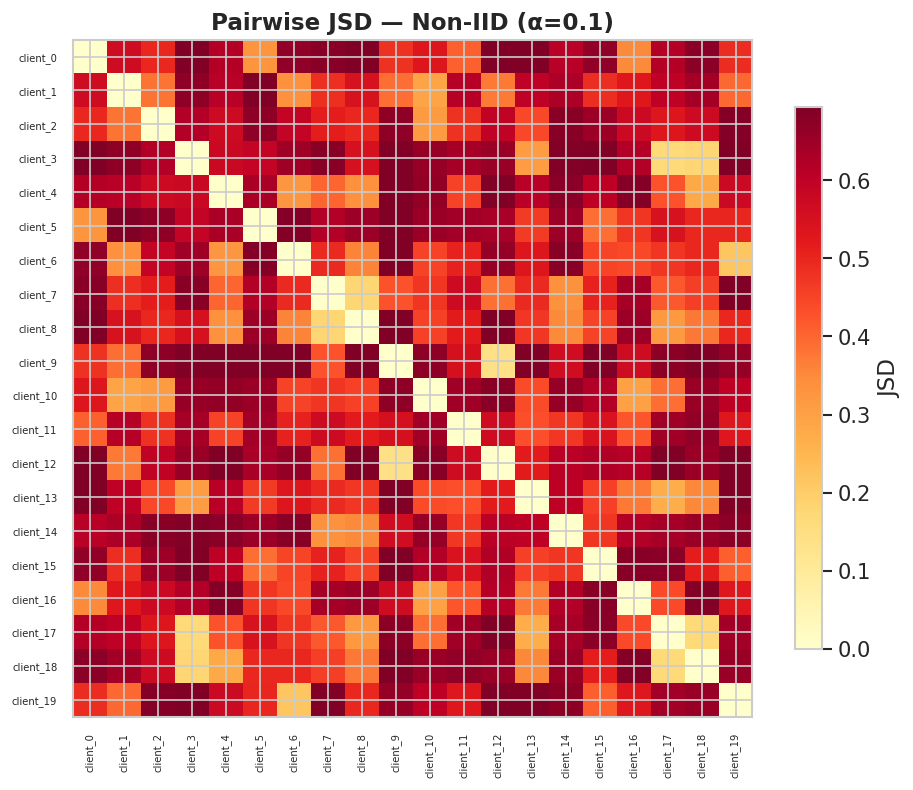

  Non-IID (α=0.1)  →  Pairwise JSD: mean=0.5437  std=0.1345  max=0.6931


In [12]:
# ============================================================
# Cell 7: Pairwise JSD heatmap between all clients
# ============================================================

for setting_name, records in all_results.items():
    sorted_recs = sorted(records, key=lambda r: int(r["client_id"]))
    n = len(sorted_recs)
    names = [r["client_name"] for r in sorted_recs]
    dists = np.array([r["cluster_dist"] for r in sorted_recs])

    # Compute pairwise JSD matrix
    jsd_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            jsd_val = js_divergence(dists[i], dists[j])
            jsd_matrix[i, j] = jsd_val
            jsd_matrix[j, i] = jsd_val

    # Plot
    size = max(8, n * 0.25)
    fig, ax = plt.subplots(figsize=(size, size * 0.85))
    im = ax.imshow(jsd_matrix, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=90, fontsize=6)
    ax.set_yticklabels(names, fontsize=6)
    ax.set_title(f"Pairwise JSD — {setting_name}")
    fig.colorbar(im, ax=ax, label="JSD", shrink=0.8)
    fig.tight_layout()
    plt.show()

    # Summary
    upper_tri = jsd_matrix[np.triu_indices(n, k=1)]
    print(f"  {setting_name}  →  Pairwise JSD: "
          f"mean={upper_tri.mean():.4f}  std={upper_tri.std():.4f}  "
          f"max={upper_tri.max():.4f}")

## 7 · Cross-Setting Comparison (IID vs Non-IID)

Setting                  #C     KL μ     KL σ   KL max     JSD μ    JSD σ  JSD max   CosSim μ
─────────────────────────────────────────────────────────────────────────────────────────────
IID  (α=100)             20   0.0093   0.0028   0.0137    0.0023   0.0007   0.0035     0.9962
Non-IID (α=0.1)          20   1.5167   0.4036   2.2099    0.3715   0.0716   0.4862     0.9370


/tmp/ipykernel_132449/3283810293.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_132449/3283810293.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
/tmp/ipykernel_132449/3283810293.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,


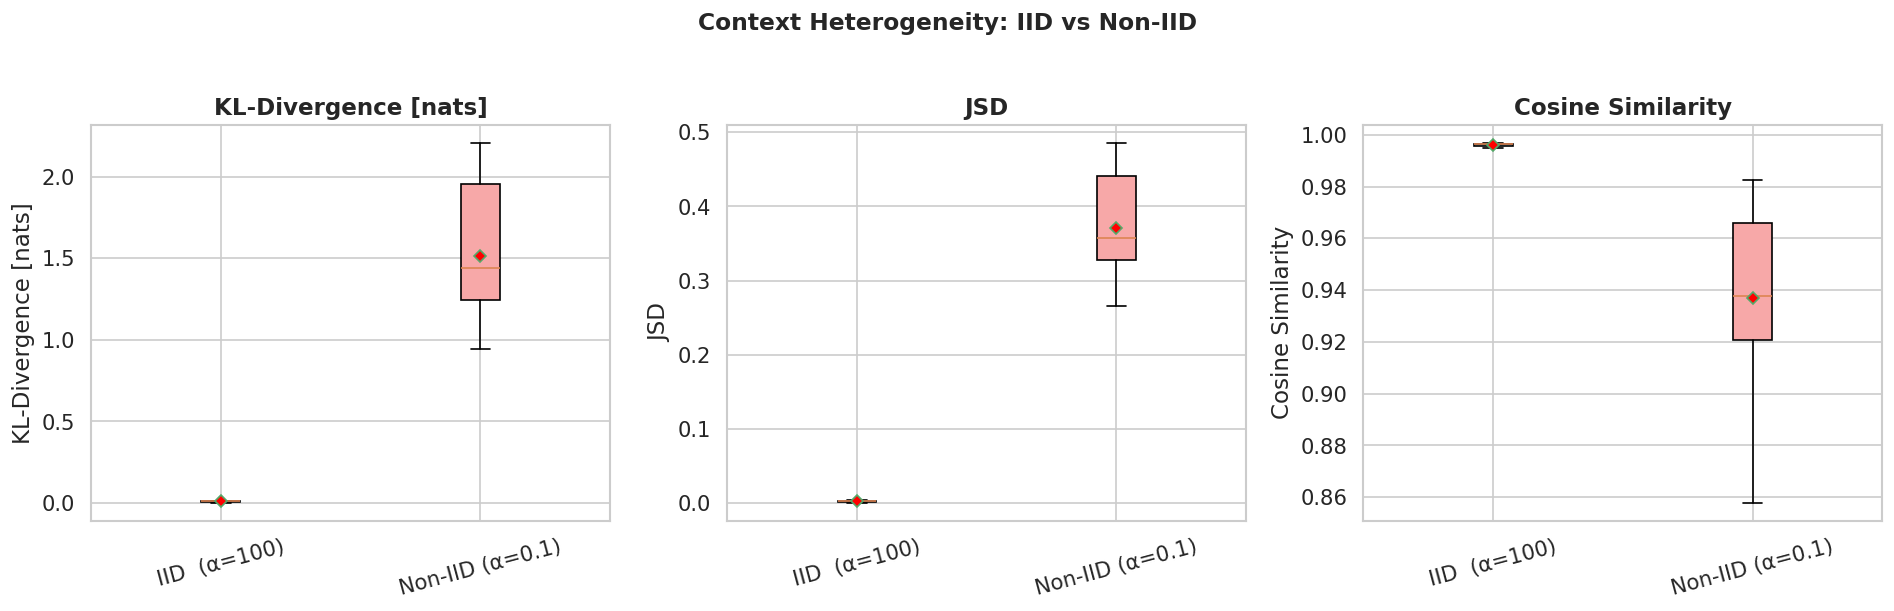

In [13]:
# ============================================================
# Cell 8: Side-by-side comparison across all partition settings
# ============================================================

# ── Aggregate stats per setting ──
summary_rows = []
for setting_name, records in all_results.items():
    kls  = [r["KL_div"]  for r in records]
    jsds = [r["JSD"]     for r in records]
    coss = [r["cos_sim"] for r in records]
    summary_rows.append({
        "Setting":      setting_name,
        "Clients":      len(records),
        "KL mean":      np.mean(kls),
        "KL std":       np.std(kls),
        "KL max":       np.max(kls),
        "JSD mean":     np.mean(jsds),
        "JSD std":      np.std(jsds),
        "JSD max":      np.max(jsds),
        "CosSim mean":  np.mean(coss),
    })

# Print comparison table
header = f"{'Setting':<22} {'#C':>4} {'KL μ':>8} {'KL σ':>8} {'KL max':>8}  {'JSD μ':>8} {'JSD σ':>8} {'JSD max':>8}  {'CosSim μ':>9}"
print(header)
print("─" * len(header))
for row in summary_rows:
    print(f"{row['Setting']:<22} {row['Clients']:>4} "
          f"{row['KL mean']:>8.4f} {row['KL std']:>8.4f} {row['KL max']:>8.4f}  "
          f"{row['JSD mean']:>8.4f} {row['JSD std']:>8.4f} {row['JSD max']:>8.4f}  "
          f"{row['CosSim mean']:>9.4f}")

# ── Box-plot comparison ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [("KL_div", "KL-Divergence [nats]"), ("JSD", "JSD"), ("cos_sim", "Cosine Similarity")]

for ax, (metric_key, metric_label) in zip(axes, metrics):
    data_for_box = []
    labels_for_box = []
    for setting_name, records in all_results.items():
        vals = [r[metric_key] for r in records]
        data_for_box.append(vals)
        labels_for_box.append(setting_name)

    bp = ax.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
                    showmeans=True, meanprops=dict(marker="D", markerfacecolor="red", markersize=5))
    colors_box = ["#a8d8ea", "#f7a8a8"]
    for patch, color in zip(bp["boxes"], colors_box[:len(bp["boxes"])]):
        patch.set_facecolor(color)
    ax.set_ylabel(metric_label)
    ax.set_title(metric_label)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Context Heterogeneity: IID vs Non-IID", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 8 · t-SNE of Embeddings Colored by Client Assignment


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Running t-SNE on 2975 × 1024 embeddings (this may take ~30s) …
✓ t-SNE done


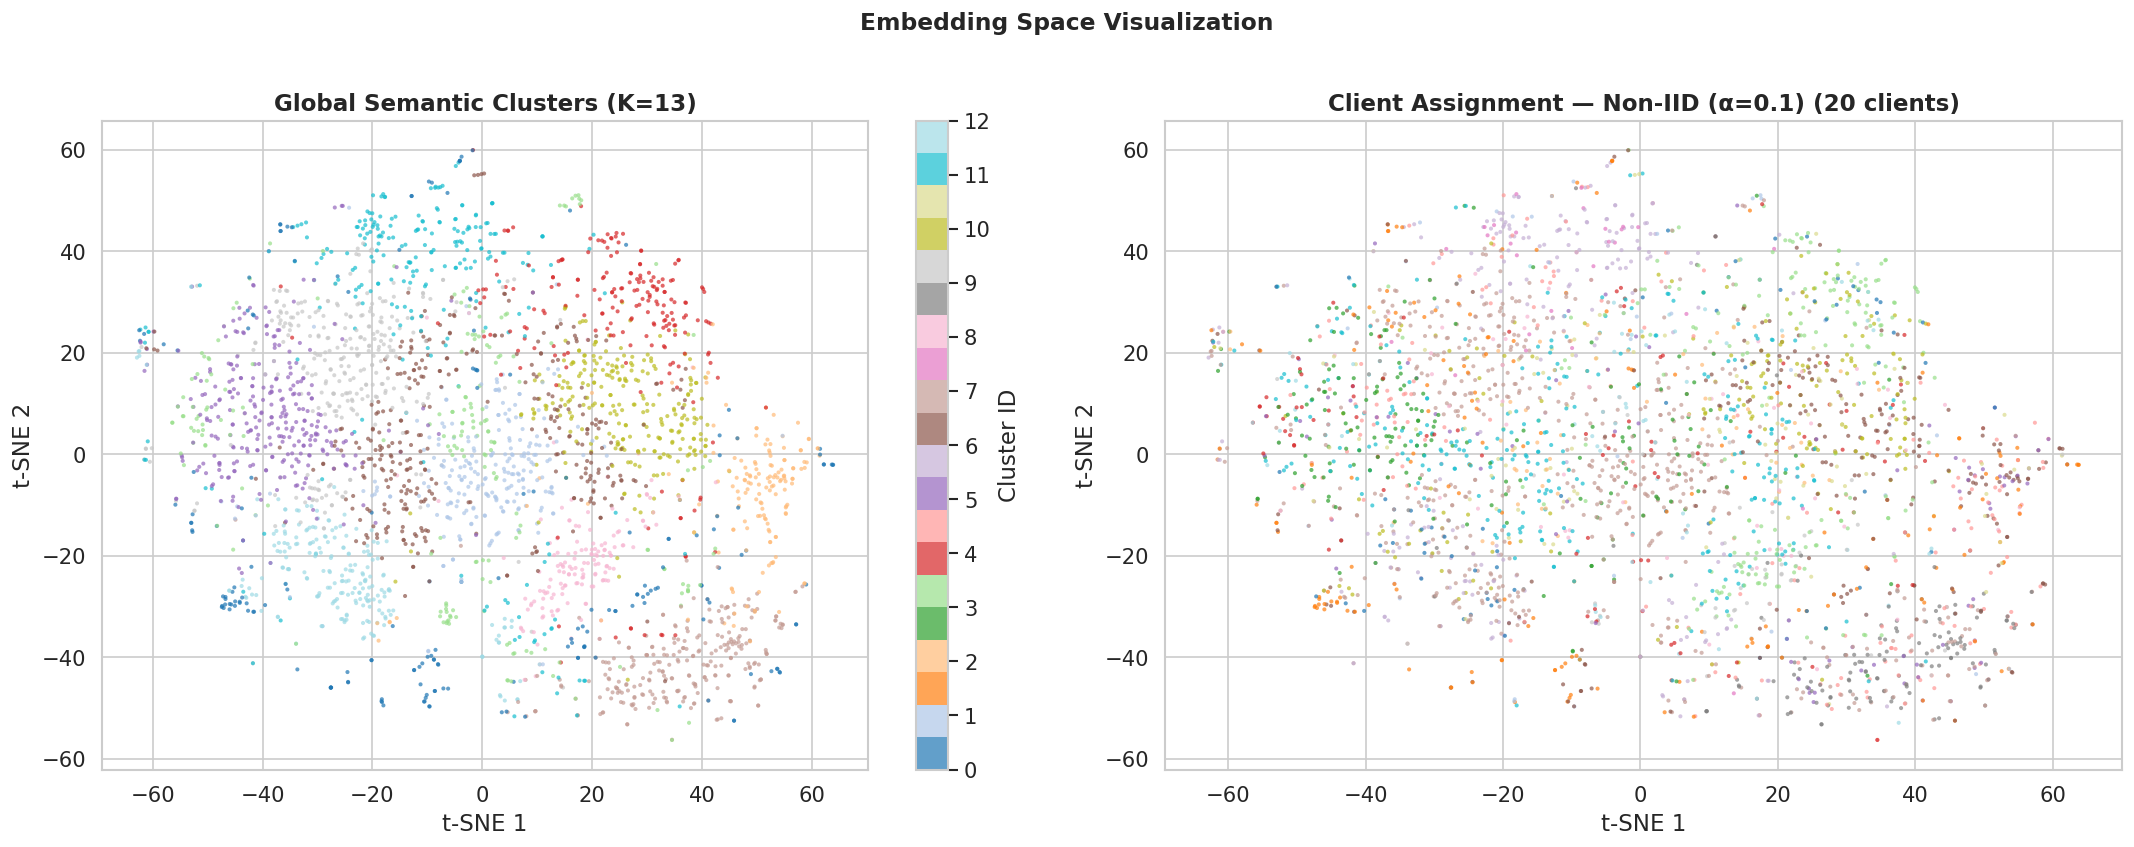

In [15]:
# ============================================================
# Cell 9: t-SNE — embeddings coloured by cluster AND by client
# ============================================================
!pip install scikit-learn --quiet
from sklearn.manifold import TSNE

print("Running t-SNE on 2975 × 1024 embeddings (this may take ~30s) …")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, init="pca")
coords = tsne.fit_transform(embeddings)   # (2975, 2)
print("✓ t-SNE done")

# ── Panel A: coloured by global cluster ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc0 = axes[0].scatter(
    coords[:, 0], coords[:, 1],
    c=cluster_labels, cmap="tab20", s=6, alpha=0.7, edgecolors="none",
)
axes[0].set_title("Global Semantic Clusters (K=13)")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
fig.colorbar(sc0, ax=axes[0], label="Cluster ID", ticks=range(K))

# ── Panel B: coloured by client (use the Non-IID setting for contrast) ──
noniid_key = [k for k in all_results if "Non-IID" in k][0]

# Build sample_index → client_id mapping from the partition JSON
partition_noniid = load_partition(PARTITION_FILES[noniid_key])
ci_noniid = map_clients_to_clusters(partition_noniid, filename_to_idx, cluster_labels, K)

client_assignment = np.full(n_samples, -1, dtype=int)
for cid, info in ci_noniid.items():
    cid_int = int(cid)
    for idx in info["global_indices"]:
        client_assignment[idx] = cid_int

n_clients_noniid = len(ci_noniid)
cmap_clients = plt.colormaps.get_cmap("tab20").resampled(n_clients_noniid)
mask = client_assignment >= 0

sc1 = axes[1].scatter(
    coords[mask, 0], coords[mask, 1],
    c=client_assignment[mask], cmap=cmap_clients, s=6, alpha=0.7, edgecolors="none",
)
axes[1].set_title(f"Client Assignment — {noniid_key} ({n_clients_noniid} clients)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

fig.suptitle("Embedding Space Visualization", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 9 · System-Level Heterogeneity Index

We define a single scalar to summarize the **overall context heterogeneity** of a partition setting:

$$\mathcal{H}_{\text{ctx}} = \frac{1}{C} \sum_{c=1}^{C} \text{JSD}(P_c \| Q)$$

This is the **mean client-vs-global JSD**. Additionally, we compute the mean **pairwise JSD** between all client pairs as a complementary measure.

In [16]:
# ============================================================
# Cell 10: System-level heterogeneity index
# ============================================================

print("=" * 65)
print("  SYSTEM-LEVEL CONTEXT HETEROGENEITY INDEX  (ℋ_ctx)")
print("=" * 65)

for setting_name, records in all_results.items():
    jsds = [r["JSD"] for r in records]
    H_ctx = np.mean(jsds)

    # Also compute mean pairwise JSD
    dists = np.array([r["cluster_dist"] for r in records])
    n = len(records)
    pw_jsds = []
    for i in range(n):
        for j in range(i + 1, n):
            pw_jsds.append(js_divergence(dists[i], dists[j]))
    H_pairwise = np.mean(pw_jsds) if pw_jsds else 0.0

    print(f"\n  {setting_name}")
    print(f"    ℋ_ctx  (mean client-vs-global JSD) = {H_ctx:.6f}")
    print(f"    ℋ_pair (mean pairwise JSD)          = {H_pairwise:.6f}")
    print(f"    Ratio  (Non-IID should be >> IID)   = —")

# ── Ratio between settings ──
keys = list(all_results.keys())
if len(keys) == 2:
    jsd_0 = np.mean([r["JSD"] for r in all_results[keys[0]]])
    jsd_1 = np.mean([r["JSD"] for r in all_results[keys[1]]])
    ratio = jsd_1 / jsd_0 if jsd_0 > 0 else float("inf")
    print(f"\n  ℋ_ctx ratio ({keys[1]} / {keys[0]}) = {ratio:.2f}×")
    print(f"  → The Non-IID setting is {ratio:.1f}× more heterogeneous than IID")

print("\n" + "=" * 65)

  SYSTEM-LEVEL CONTEXT HETEROGENEITY INDEX  (ℋ_ctx)

  IID  (α=100)
    ℋ_ctx  (mean client-vs-global JSD) = 0.002344
    ℋ_pair (mean pairwise JSD)          = 0.004923
    Ratio  (Non-IID should be >> IID)   = —

  Non-IID (α=0.1)
    ℋ_ctx  (mean client-vs-global JSD) = 0.371459
    ℋ_pair (mean pairwise JSD)          = 0.543709
    Ratio  (Non-IID should be >> IID)   = —

  ℋ_ctx ratio (Non-IID (α=0.1) / IID  (α=100)) = 158.45×
  → The Non-IID setting is 158.5× more heterogeneous than IID



## 10 · Client-to-Client Similarity Analysis

For every client pair $(c_i, c_j)$ we already have the **pairwise JSD** from Section 6.
We now reuse that distance matrix to:

1. **Rank nearest / farthest neighbours** for each client.
2. Build a **hierarchical clustering dendrogram** (Ward linkage on JSD).
3. Show a **cluster-reordered heatmap** so similar clients appear adjacent.
4. Identify the **most central** and **most isolated** clients.


  CLIENT SIMILARITY — IID  (α=100)

  Top-5 most SIMILAR neighbours per client (lowest pairwise JSD):
  Client         │ Nearest Neighbours (name: JSD)
  ───────────────┼─────────────────────────────────────────────────────
  client_0       │ client_12: 0.0028, client_17: 0.0029, client_11: 0.0031, client_19: 0.0039, client_2: 0.0044
  client_1       │ client_12: 0.0025, client_13: 0.0034, client_15: 0.0035, client_14: 0.0037, client_17: 0.0041
  client_2       │ client_19: 0.0020, client_17: 0.0022, client_12: 0.0027, client_15: 0.0032, client_7: 0.0032
  client_3       │ client_6: 0.0027, client_12: 0.0028, client_16: 0.0035, client_4: 0.0042, client_14: 0.0043
  client_4       │ client_10: 0.0029, client_12: 0.0031, client_6: 0.0032, client_17: 0.0034, client_2: 0.0040
  client_5       │ client_8: 0.0024, client_13: 0.0031, client_11: 0.0038, client_2: 0.0039, client_12: 0.0039
  client_6       │ client_3: 0.0027, client_14: 0.0029, client_9: 0.0030, client_4: 0.0032, client_12: 0.

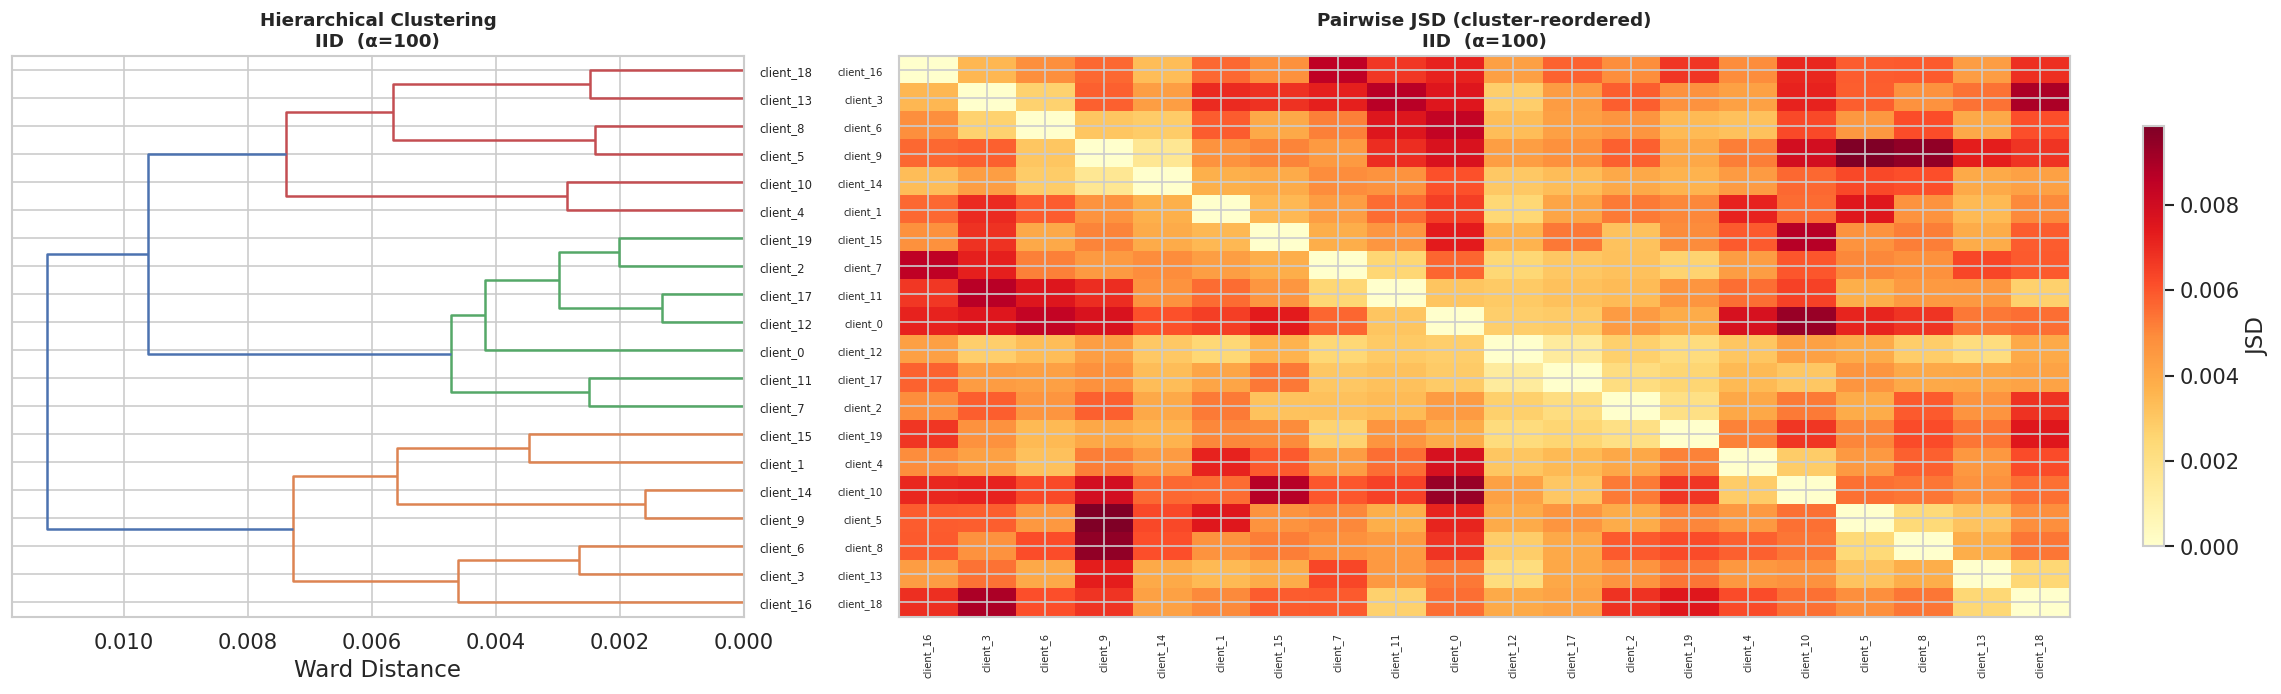

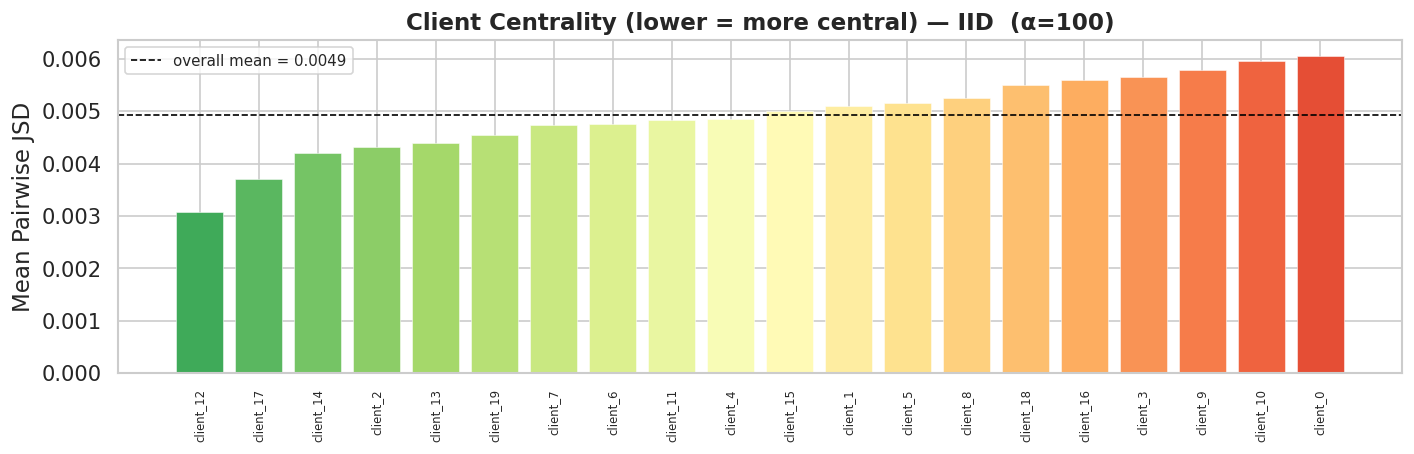


  CLIENT SIMILARITY — Non-IID (α=0.1)

  Top-5 most SIMILAR neighbours per client (lowest pairwise JSD):
  Client         │ Nearest Neighbours (name: JSD)
  ───────────────┼─────────────────────────────────────────────────────
  client_0       │ client_5: 0.3266, client_16: 0.3498, client_11: 0.4074, client_9: 0.4768, client_19: 0.4891
  client_1       │ client_10: 0.2912, client_6: 0.3359, client_12: 0.3726, client_2: 0.3798, client_9: 0.3876
  client_2       │ client_10: 0.3115, client_1: 0.3798, client_13: 0.4420, client_11: 0.4777, client_8: 0.4967
  client_3       │ client_17: 0.1663, client_18: 0.1811, client_13: 0.3113, client_8: 0.5492, client_4: 0.5777
  client_4       │ client_18: 0.2804, client_6: 0.3244, client_8: 0.3383, client_7: 0.4016, client_17: 0.4262
  client_5       │ client_0: 0.3266, client_15: 0.3895, client_13: 0.4636, client_16: 0.4727, client_18: 0.4965
  client_6       │ client_19: 0.2144, client_4: 0.3244, client_1: 0.3359, client_8: 0.3588, client_16: 0.44

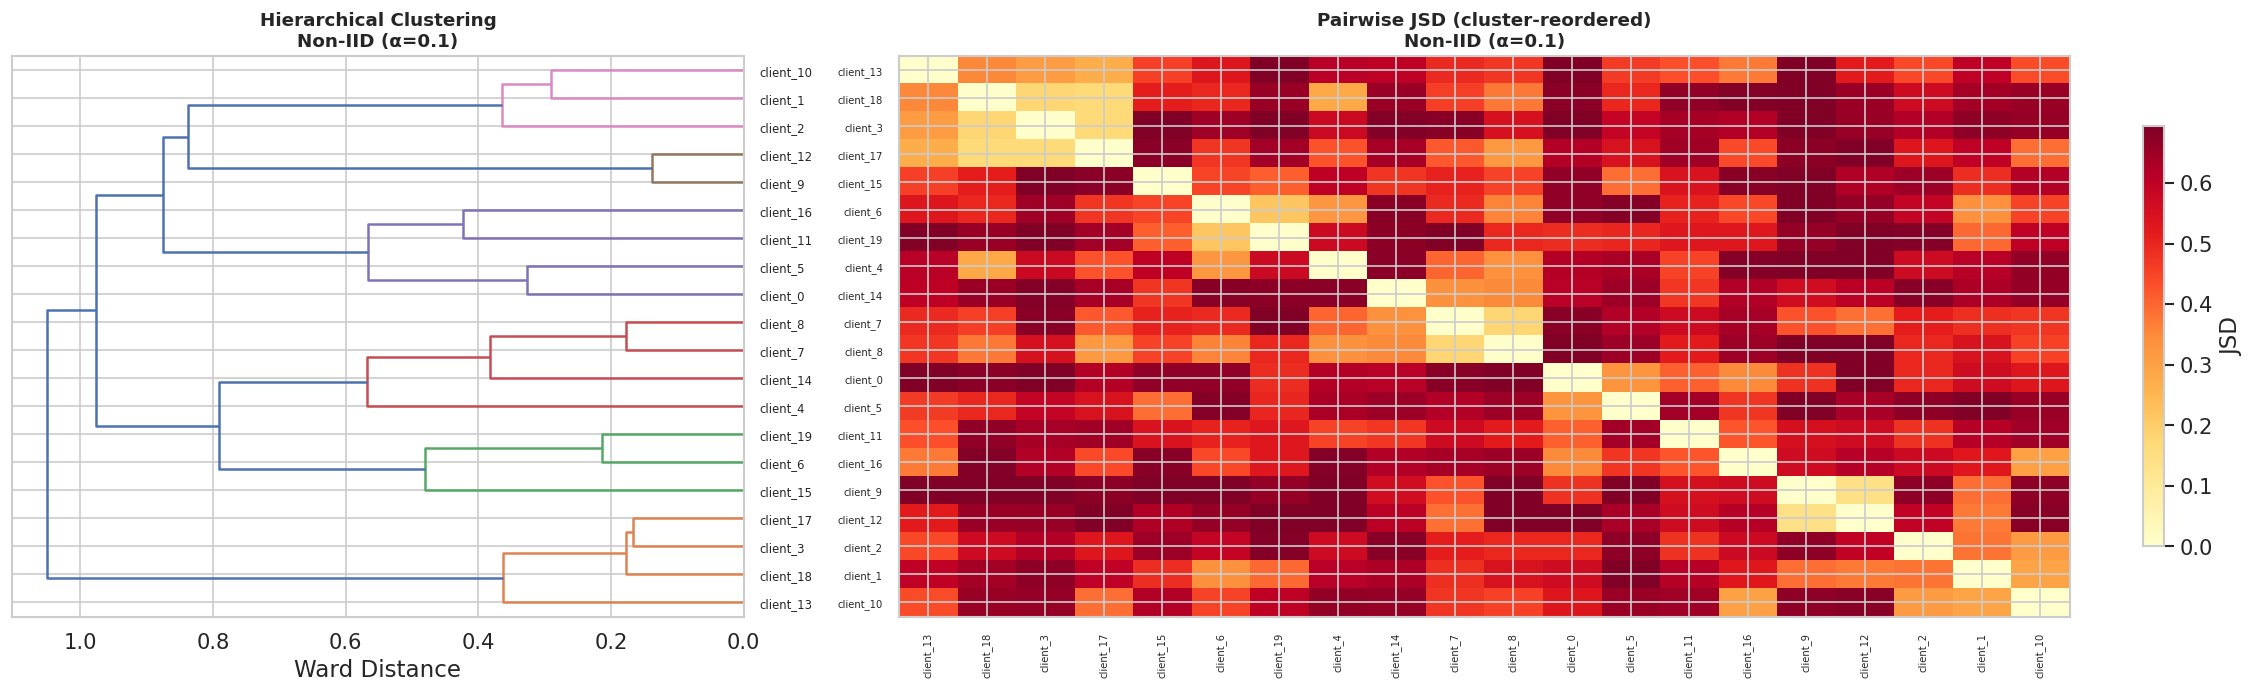

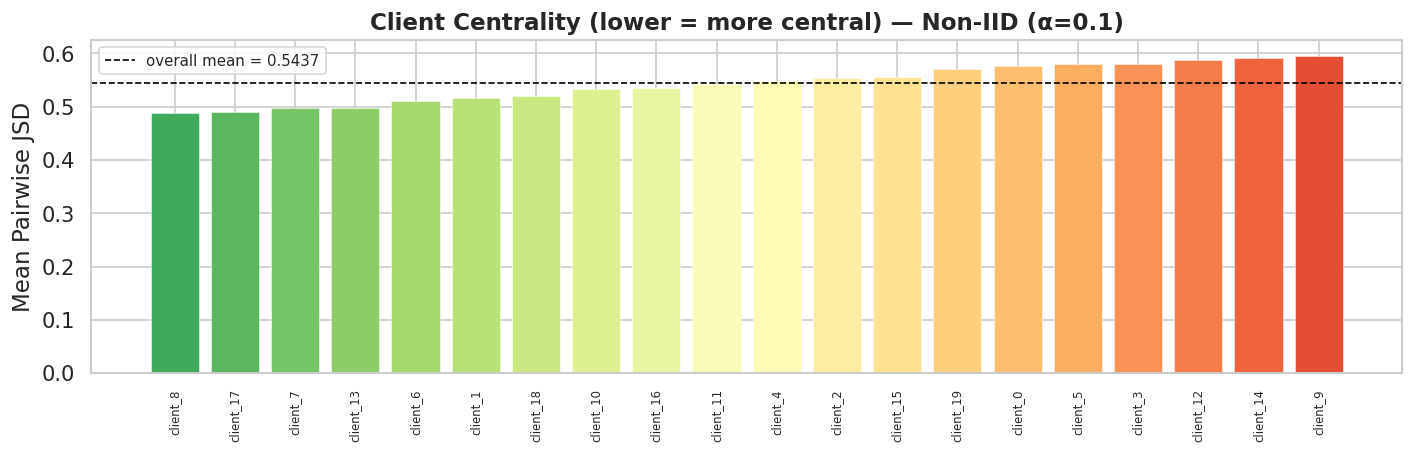

In [17]:
# ============================================================
# Cell 11: Client-to-Client Similarity — neighbours, dendrogram,
#           reordered heatmap, central / isolated clients
# ============================================================
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

TOP_K = 5   # number of nearest / farthest neighbours to show

for setting_name, records in all_results.items():
    sorted_recs = sorted(records, key=lambda r: int(r["client_id"]))
    n = len(sorted_recs)
    names = [r["client_name"] for r in sorted_recs]
    dists = np.array([r["cluster_dist"] for r in sorted_recs])

    # ── 1) Build pairwise JSD matrix ──
    jsd_mat = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            val = js_divergence(dists[i], dists[j])
            jsd_mat[i, j] = val
            jsd_mat[j, i] = val

    # ── 2) Nearest & farthest neighbours ──
    top_k = min(TOP_K, n - 1)
    print(f"\n{'='*70}")
    print(f"  CLIENT SIMILARITY — {setting_name}")
    print(f"{'='*70}")
    print(f"\n  Top-{top_k} most SIMILAR neighbours per client (lowest pairwise JSD):")
    print(f"  {'Client':<14} │ {'Nearest Neighbours (name: JSD)'}")
    print(f"  {'─'*14}─┼─{'─'*52}")

    mean_jsd_per_client = []
    for i in range(n):
        row = jsd_mat[i].copy()
        row[i] = np.inf                       # exclude self
        order = np.argsort(row)
        nearest = [(names[j], row[j]) for j in order[:top_k]]
        nearest_str = ", ".join(f"{nm}: {v:.4f}" for nm, v in nearest)
        print(f"  {names[i]:<14} │ {nearest_str}")
        mean_jsd_per_client.append(np.mean(row[row < np.inf]))

    # ── 3) Most central & most isolated clients ──
    mean_jsd_arr = np.array(mean_jsd_per_client)
    central_idx  = int(np.argmin(mean_jsd_arr))
    isolated_idx = int(np.argmax(mean_jsd_arr))
    print(f"\n  ★ Most CENTRAL client  (lowest mean JSD to others): "
          f"{names[central_idx]}  (mean JSD = {mean_jsd_arr[central_idx]:.4f})")
    print(f"  ★ Most ISOLATED client (highest mean JSD to others): "
          f"{names[isolated_idx]}  (mean JSD = {mean_jsd_arr[isolated_idx]:.4f})")

    # ── 4) Hierarchical clustering dendrogram ──
    condensed = squareform(jsd_mat, checks=False)
    Z = linkage(condensed, method="ward")

    fig, axes = plt.subplots(1, 2, figsize=(20, max(6, n * 0.18)),
                             gridspec_kw={"width_ratios": [1, 2]})

    # Dendrogram
    dn = dendrogram(
        Z, labels=names, orientation="left", ax=axes[0],
        leaf_font_size=7, color_threshold=0.7 * max(Z[:, 2]),
    )
    axes[0].set_title(f"Hierarchical Clustering\n{setting_name}", fontsize=11)
    axes[0].set_xlabel("Ward Distance")

    # ── 5) Cluster-reordered heatmap ──
    leaf_order = dn["leaves"]   # reordered indices from dendrogram
    reordered_mat   = jsd_mat[np.ix_(leaf_order, leaf_order)]
    reordered_names = [names[i] for i in leaf_order]

    im = axes[1].imshow(reordered_mat, cmap="YlOrRd", aspect="auto")
    axes[1].set_xticks(range(n))
    axes[1].set_yticks(range(n))
    axes[1].set_xticklabels(reordered_names, rotation=90, fontsize=6)
    axes[1].set_yticklabels(reordered_names, fontsize=6)
    axes[1].set_title(f"Pairwise JSD (cluster-reordered)\n{setting_name}", fontsize=11)
    fig.colorbar(im, ax=axes[1], label="JSD", shrink=0.75)

    fig.tight_layout()
    plt.show()

    # ── 6) Bar chart: mean JSD per client (centrality) ──
    sort_idx = np.argsort(mean_jsd_arr)
    fig2, ax2 = plt.subplots(figsize=(max(12, n * 0.3), 4))
    colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, n))
    ax2.bar(range(n),
            mean_jsd_arr[sort_idx],
            color=colors,
            edgecolor="white", lw=0.3)
    ax2.set_xticks(range(n))
    ax2.set_xticklabels([names[i] for i in sort_idx], rotation=90, fontsize=7)
    ax2.set_ylabel("Mean Pairwise JSD")
    ax2.set_title(f"Client Centrality (lower = more central) — {setting_name}")
    ax2.axhline(mean_jsd_arr.mean(), ls="--", color="black", lw=1,
                label=f"overall mean = {mean_jsd_arr.mean():.4f}")
    ax2.legend(fontsize=9)
    fig2.tight_layout()
    plt.show()